In [4]:
import numpy as np

# Load the toy array
Toy_array = np.load("toy_corpus.npy")
print(Toy_array.shape)  # Should be (10, 14, 256)

(10, 14, 256)


In [6]:
import pickle
pc = pickle.load(open(f'/home/navid/emotiv-ml/axon/pickle/prep_c_{2}_{0.75}_{9}.pickle', 'rb'))

/home/navid/anaconda3/envs/myenv/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 0.23.2 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [81]:
Toy_padded_array = np.pad(Toy_array, ((0, 0), (0, 0), (0, 1)), mode='constant')
print(Toy_padded_array.shape)

(10, 14, 257)


In [82]:
Toy_Clean = pc.clean(Toy_padded_array[0].T)

cleaning...
data cleaned and reconstructed 
 transform in 2ms (2.48ms/epoch)
(1, 256, 14)
(256, 14) (257, 14)


In [83]:
import os
import mne
montage_file = os.path.join(os.getcwd(),'Cap_locations/Standard-10-20-Cap14.locs')
mont = mne.channels.read_custom_montage(montage_file)
# mont.plot()


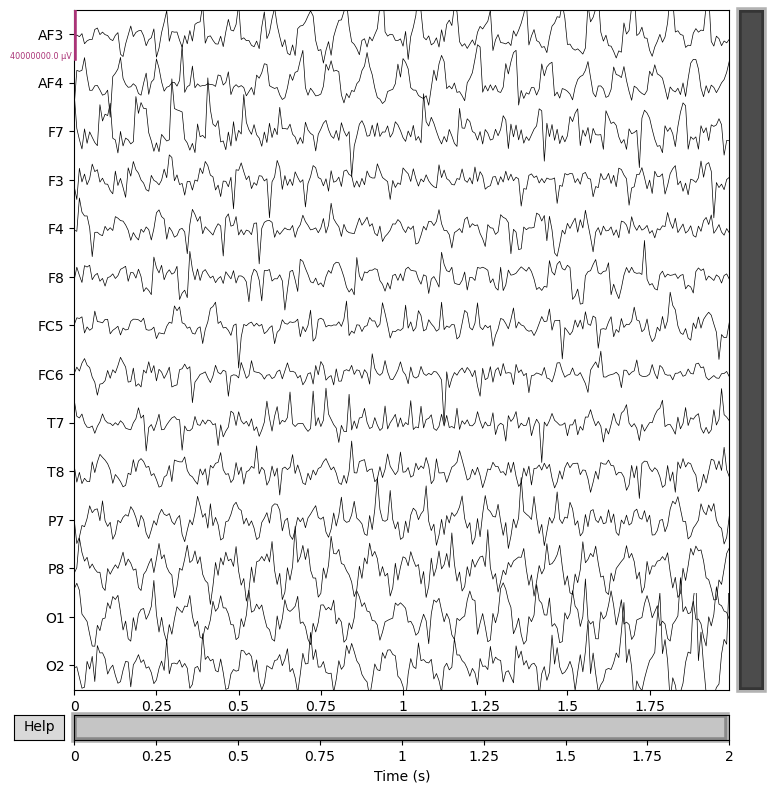

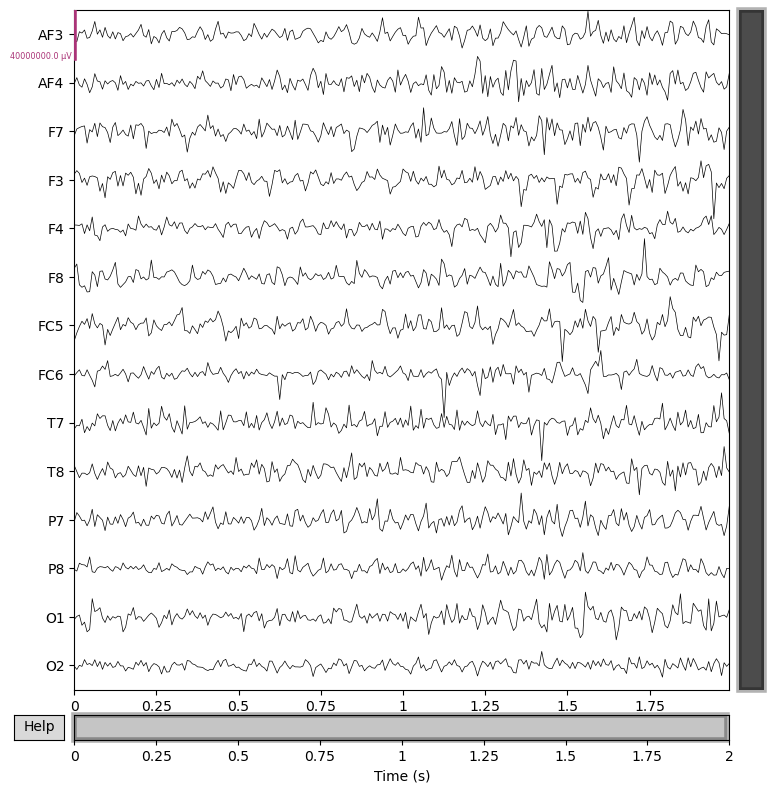

In [84]:
%matplotlib inline 

import mne
import matplotlib.pyplot as plt

# Create MNE info
Epoch_info = mne.create_info(ch_names=mont.ch_names, sfreq=128., ch_types='eeg')

# Create RawArray objects
Toy_mne = mne.io.RawArray(Toy_array[0], info=Epoch_info, verbose=0) 
Toy_Clean_mne = mne.io.RawArray(Toy_Clean.T, info=Epoch_info, verbose=0) 

# Plot in separate figures (since MNE creates standalone figures)
fig1 = Toy_mne.plot(start=0, duration=2, scalings='20')
fig2 = Toy_Clean_mne.plot(start=0, duration=2, scalings='20')

plt.show()  # Ensure figures appear in Jupyter



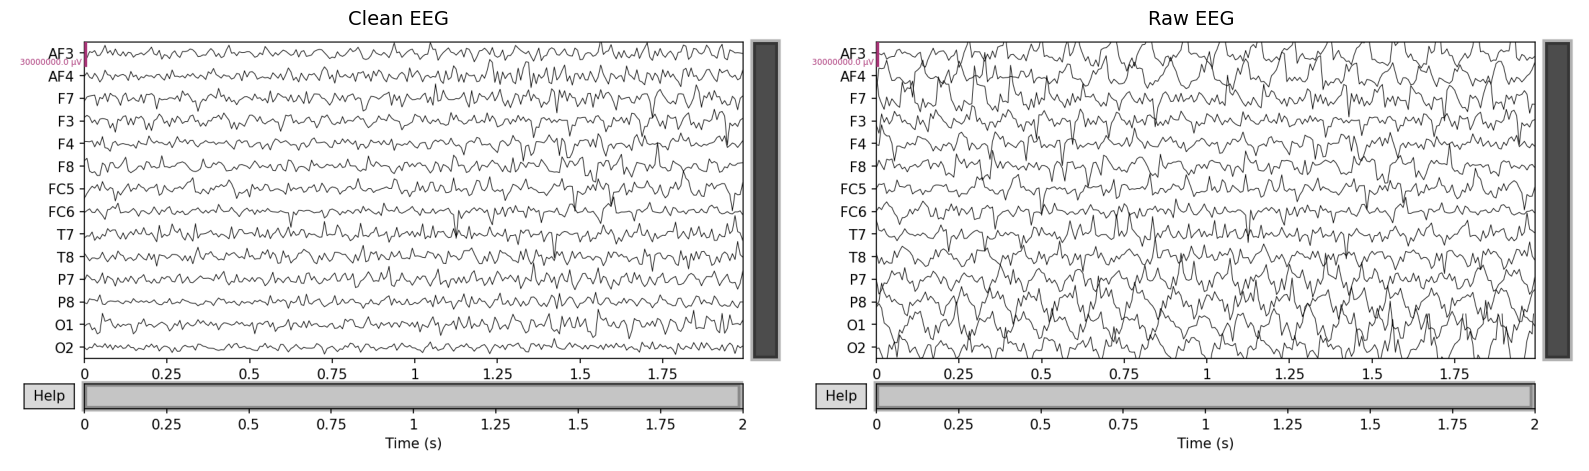

In [85]:
%matplotlib inline
import mne
import matplotlib.pyplot as plt
from io import BytesIO
from PIL import Image

# Create MNE info
Epoch_info = mne.create_info(ch_names=mont.ch_names, sfreq=128., ch_types='eeg')

# Create RawArray objects
Toy_mne = mne.io.RawArray(Toy_array[0], info=Epoch_info, verbose=0)
Toy_Clean_mne = mne.io.RawArray(Toy_Clean.T, info=Epoch_info, verbose=0)

# Function to save MNE plots as images in memory
def get_plot_image(raw, title):
    buffer = BytesIO()
    fig = raw.plot(start=0, duration=2, scalings='15', title=title, show=False)
    fig.set_size_inches(8, 4)  # Make each plot bigger
    fig.savefig(buffer, format='png', bbox_inches='tight', dpi=150)  # Higher resolution
    plt.close(fig)
    buffer.seek(0)
    return Image.open(buffer)

# Get images of the plots
clean_img = get_plot_image(Toy_Clean_mne, "Clean EEG")
noisy_img = get_plot_image(Toy_mne, "Noisy EEG")

# Display them side by side using Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Bigger figure

axes[0].imshow(clean_img)
axes[0].axis("off")  # Hide axes
axes[0].set_title("Clean EEG", fontsize=14)

axes[1].imshow(noisy_img)
axes[1].axis("off")
axes[1].set_title("Raw EEG", fontsize=14)

plt.tight_layout()
plt.show()



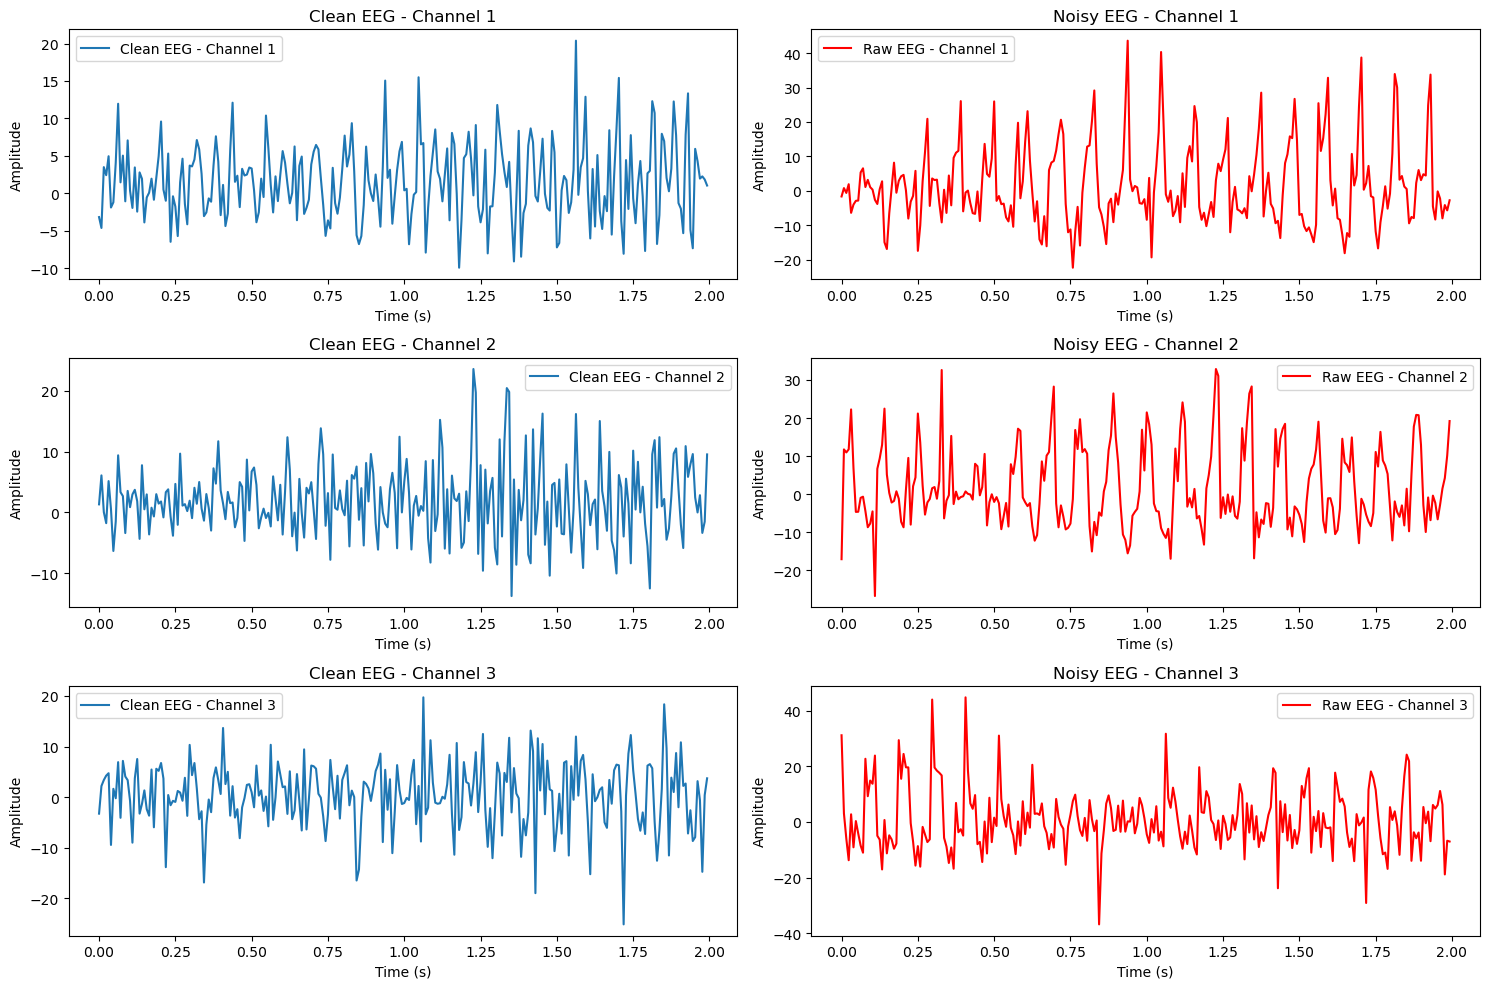

In [86]:
import numpy as np
import matplotlib.pyplot as plt

# Extract EEG data
times = np.arange(Toy_Clean_mne.n_times) / Toy_Clean_mne.info['sfreq']
clean_data = Toy_Clean_mne.get_data()[:3]  # First 3 channels
noisy_data = Toy_mne.get_data()[:3]  # First 3 channels

# Create a side-by-side plot for 3 channels
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# Loop over the first 3 channels for clean and noisy data
for i in range(3):
    axes[i, 0].plot(times, clean_data[i], label=f"Clean EEG - Channel {i+1}")
    axes[i, 0].set_title(f"Clean EEG - Channel {i+1}")
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].legend()

    axes[i, 1].plot(times, noisy_data[i], label=f"Raw EEG - Channel {i+1}", color='r')
    axes[i, 1].set_title(f"Noisy EEG - Channel {i+1}")
    axes[i, 1].set_xlabel("Time (s)")
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


In [95]:
Toy_padded_array = np.pad(Toy_array, ((0, 0), (0, 0), (0, 1)), mode='constant')
print(Toy_padded_array.shape)
Toy_Clean = pc.clean(Toy_padded_array[1].T)

(10, 14, 257)
cleaning...
data cleaned and reconstructed 
 transform in 2ms (2.22ms/epoch)
(1, 256, 14)
(256, 14) (257, 14)


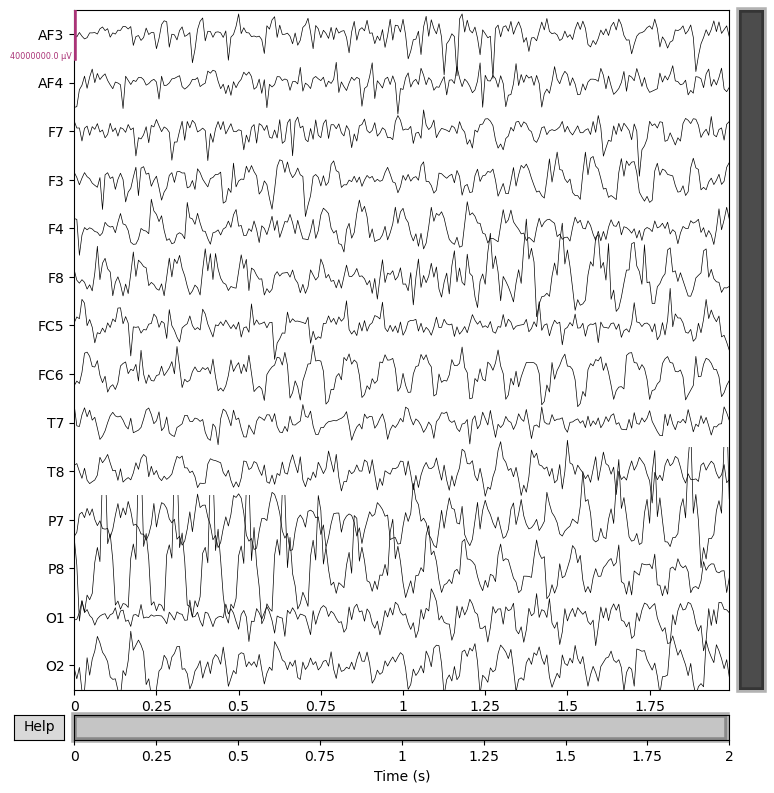

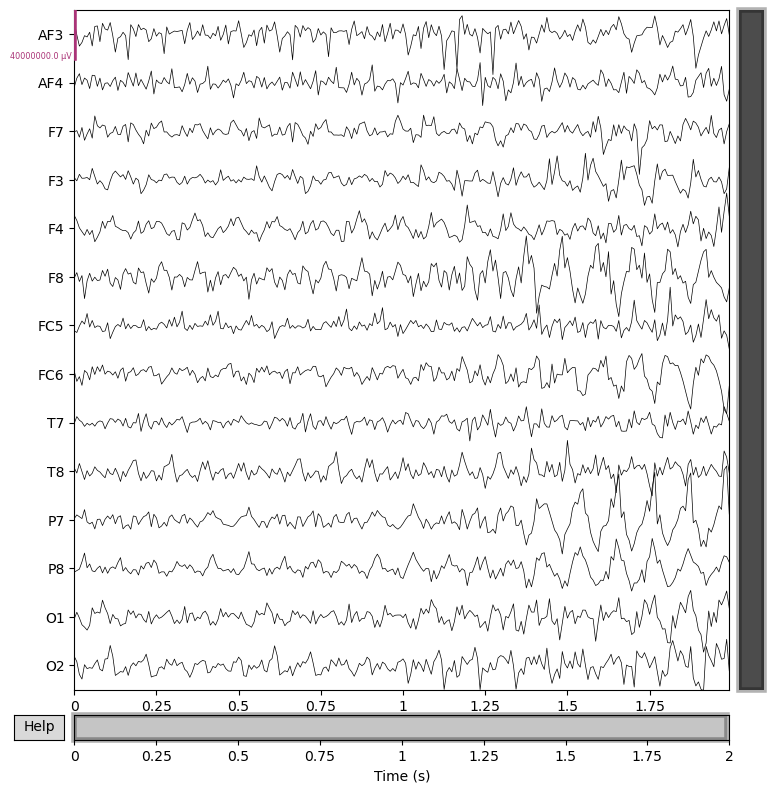

In [96]:
%matplotlib inline 

import mne
import matplotlib.pyplot as plt

# Create MNE info
Epoch_info = mne.create_info(ch_names=mont.ch_names, sfreq=128., ch_types='eeg')

# Create RawArray objects
Toy_mne = mne.io.RawArray(Toy_array[1], info=Epoch_info, verbose=0) 
Toy_Clean_mne = mne.io.RawArray(Toy_Clean.T, info=Epoch_info, verbose=0) 

# Plot in separate figures (since MNE creates standalone figures)
fig1 = Toy_mne.plot(start=0, duration=2, scalings='20')
fig2 = Toy_Clean_mne.plot(start=0, duration=3, scalings='20')

plt.show()  # Ensure figures appear in Jupyter

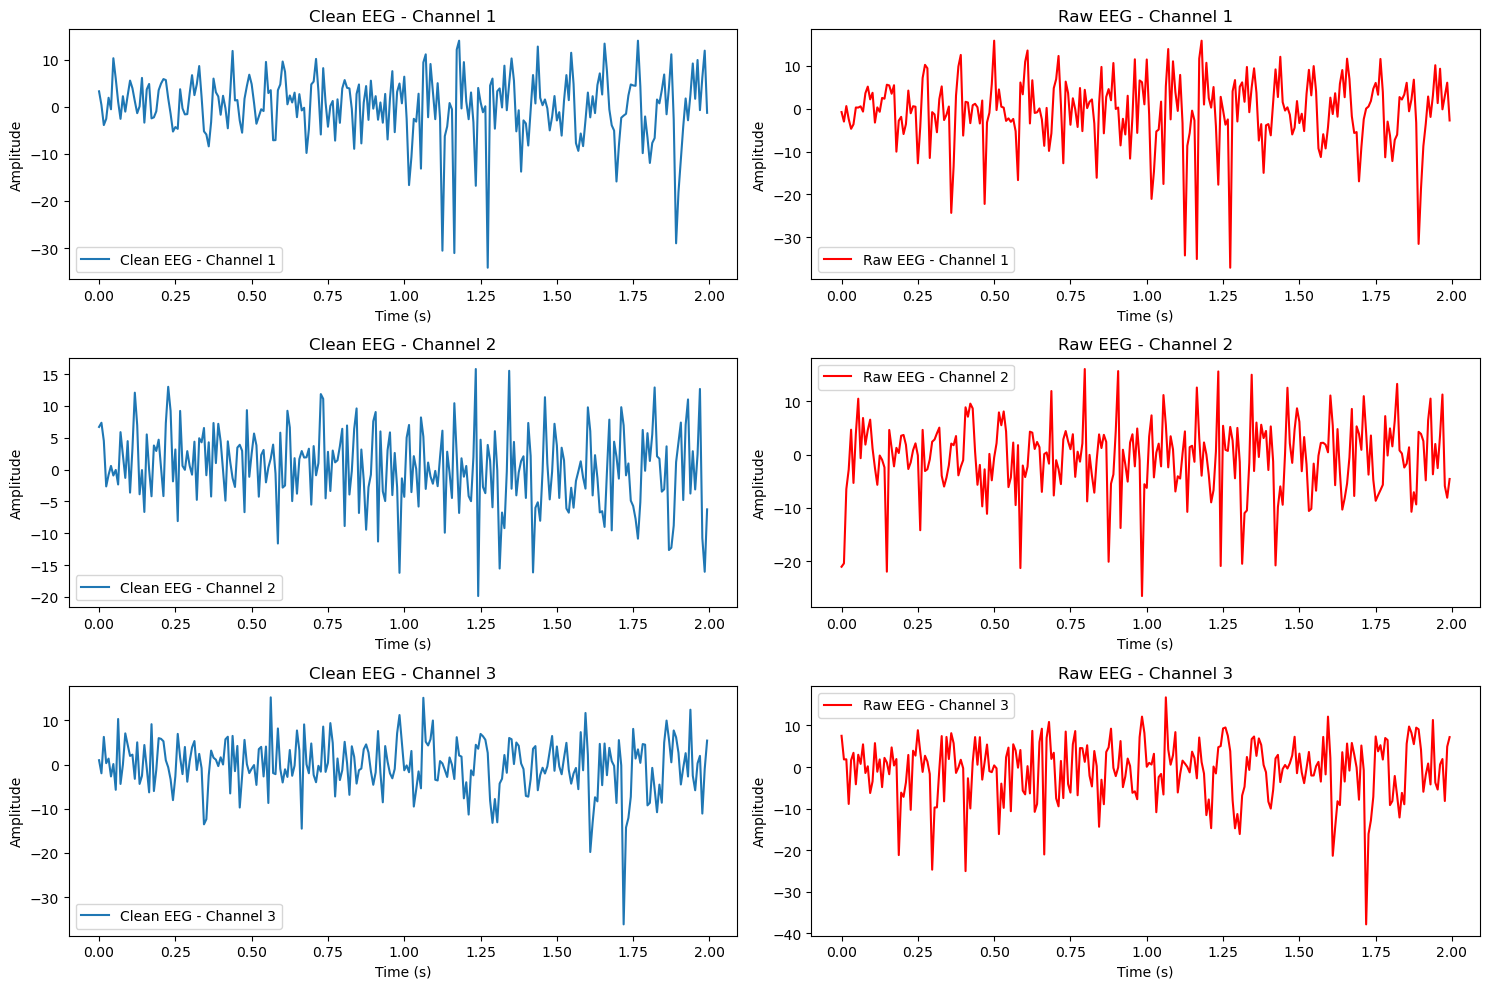

In [92]:
import numpy as np
import matplotlib.pyplot as plt

# Extract EEG data
times = np.arange(Toy_Clean_mne.n_times) / Toy_Clean_mne.info['sfreq']
clean_data = Toy_Clean_mne.get_data()[:3]  # First 3 channels
noisy_data = Toy_mne.get_data()[:3]  # First 3 channels

# Create a side-by-side plot for 3 channels
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

# Loop over the first 3 channels for clean and noisy data
for i in range(3):
    axes[i, 0].plot(times, clean_data[i], label=f"Clean EEG - Channel {i+1}")
    axes[i, 0].set_title(f"Clean EEG - Channel {i+1}")
    axes[i, 0].set_xlabel("Time (s)")
    axes[i, 0].set_ylabel("Amplitude")
    axes[i, 0].legend()

    axes[i, 1].plot(times, noisy_data[i], label=f"Raw EEG - Channel {i+1}", color='r')
    axes[i, 1].set_title(f"Raw EEG - Channel {i+1}")
    axes[i, 1].set_xlabel("Time (s)")
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()